# Eksperimen Model: CNN (Convolutional Neural Network)
Berbeda dengan model klasik yang memproses suara sebagai angka mentah (1D), CNN memproses suara sebagai **GAMBAR 2D** (seperti Spectrogram). Ini membuat CNN jauh lebih cerdas dalam mengenali letak tinggi-rendahnya nada.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print('Library Siap!')

Library Siap!


### 1. Memuat Matriks Data Berdimensi 2D

In [18]:
# Memuat file hasil ekstraksi
X = np.load('X_features_2d_preprocessed.npy')
y = np.load('y_labels_preprocessed.npy')

# Menambah dimensi Channel (karena CNN melihat ini layaknya gambar hitam putih / grayscale)
X = X[..., np.newaxis]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Bentuk Data Latih (X_train) : {X_train.shape}")
print(f"Bentuk Data Uji (X_test)    : {X_test.shape}")

Bentuk Data Latih (X_train) : (504, 40, 100, 1)
Bentuk Data Uji (X_test)    : (126, 40, 100, 1)


### 2. Membangun Arsitektur Deep Learning (CNN)

In [19]:
model_cnn = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2], 1)), # Layer Input Formal
    
    # Blok Konvolusi Pertama (Mencari pola nada dasar)
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(),
    
    # Blok Konvolusi Kedua (Mencari pola suku kata yang lebih rumit)
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(),
    
    # Jembatan ke Otak Pemutus (MLP)
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4), # Mencegah AI menghafal data (Overfitting)
    
    # Pintu Keluar: 7 Kelas Bahasa Daerah
    Dense(7, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 38, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 19, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 19, 49, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 17, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 23, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 23, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 11776)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,507,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,527,559 (5.83 MB)

 Trainable params: 1,527,367 (5.83 MB)

 Non-trainable params: 192 (768.00 B)

### 3. Pelatihan Model (Training)

In [20]:
# Early stopping: Berhenti jika dalam 10 Epoch tidak ada perkembangan
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.1787 - loss: 3.9629 - val_accuracy: 0.1089 - val_loss: 4.4317
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.3573 - loss: 1.8089 - val_accuracy: 0.2376 - val_loss: 3.2312
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.3821 - loss: 1.6051 - val_accuracy: 0.2574 - val_loss: 2.4697
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.4318 - loss: 1.4756 - val_accuracy: 0.2178 - val_loss: 3.4130
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.5112 - loss: 1.2679 - val_accuracy: 0.2277 - val_loss: 3.0372
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.5385 - loss: 1.1561 - val_accuracy: 0.4158 - val_loss: 2.2210
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.6005 - loss: 1.0474 - val_accuracy: 0.4455 - val_loss: 1.9503
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.6203 - loss: 0.9479 - val_accuracy: 0.4554 -

### 4. Evaluasi & Visualisasi

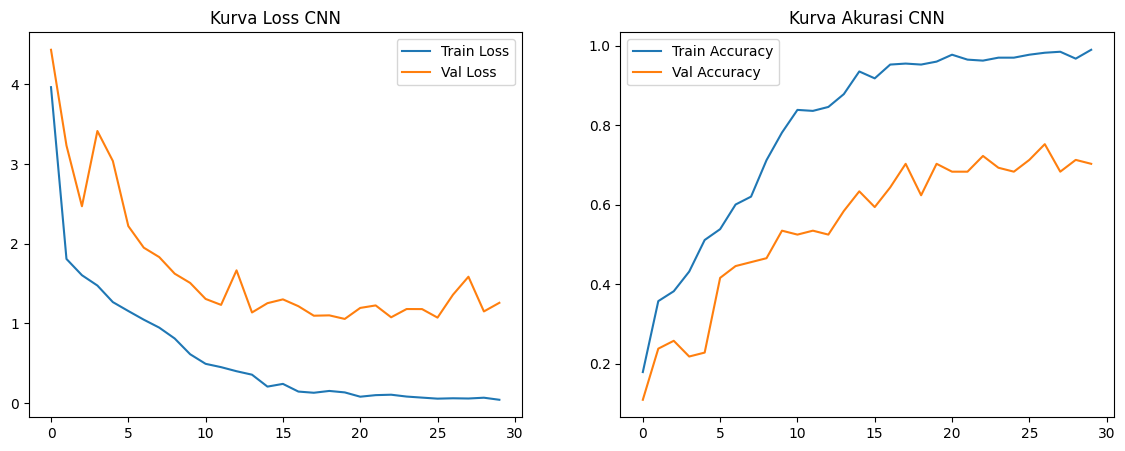

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

Classification Report:
               precision    recall  f1-score   support

       horas       0.67      0.67      0.67        18
  sampurasun       0.54      0.72      0.62        18
adilkatalino       0.60      0.67      0.63        18
      wawawa       0.72      0.72      0.72        18
   kulanuwun       0.55      0.61      0.58        18
       tabea       0.47      0.39      0.42        18
     peuhaba       0.64      0.39      0.48        18

    accuracy                           0.60       126
   macro avg       0.60      0.60      0.59       126
weighted avg       0.60      0.60      0.59       126



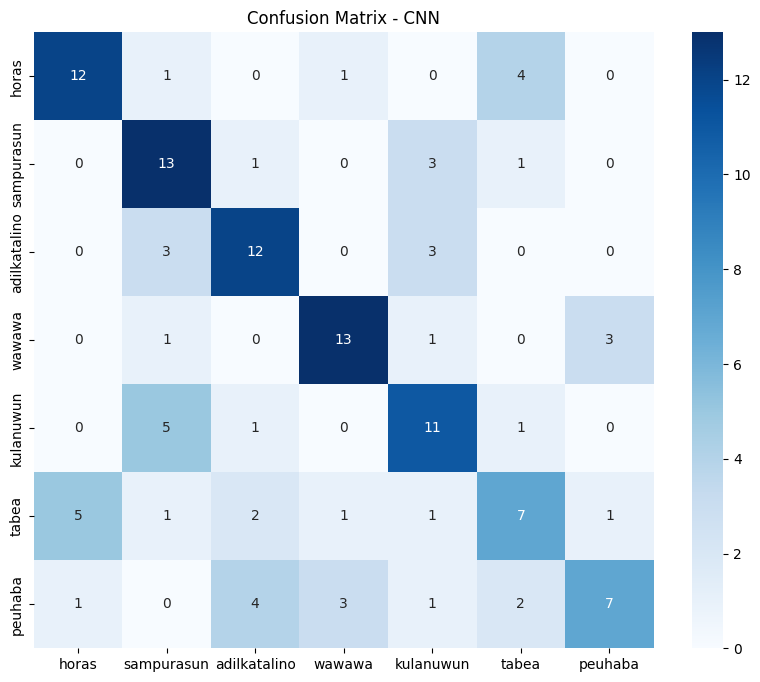

In [21]:
# A. Learning Curve
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('Kurva Loss CNN')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title('Kurva Akurasi CNN')
plt.legend()
plt.show()

# B. Confusion Matrix
y_pred_probs = model_cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

classes = ['horas', 'sampurasun', 'adilkatalino', 'wawawa', 'kulanuwun', 'tabea', 'peuhaba']
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=classes))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - CNN')
plt.show()

### 5. Simpan Model

In [16]:
import os
os.makedirs('models', exist_ok=True)
model_cnn.save('models/cnn_model.h5')
print('Model CNN berhasil disimpan!')

Model CNN berhasil disimpan!
